<a href="https://colab.research.google.com/github/Dilip-S/backprop-from-scratch/blob/main/backprop_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backpropagation From Scratch
## Learning XOR with a 2-Layer Neural Network

XOR is the classic problem that cannot be solved by a single neuron
(linear classifier). It requires a hidden layer and backpropagation
to learn. This makes it the simplest possible demonstration of a
deep network actually learning.

## XOR Truth Table
XOR (Exclusive OR) returns 1 only when inputs differ.
This cannot be separated by a single straight line —
it requires a hidden layer to learn a non-linear boundary.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
# Input: all combinations of 0 and 1
# Output: XOR result
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input X:")
print(X)
print("\nTarget y (XOR):")
print(y)

Input X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Target y (XOR):
[[0]
 [1]
 [1]
 [0]]


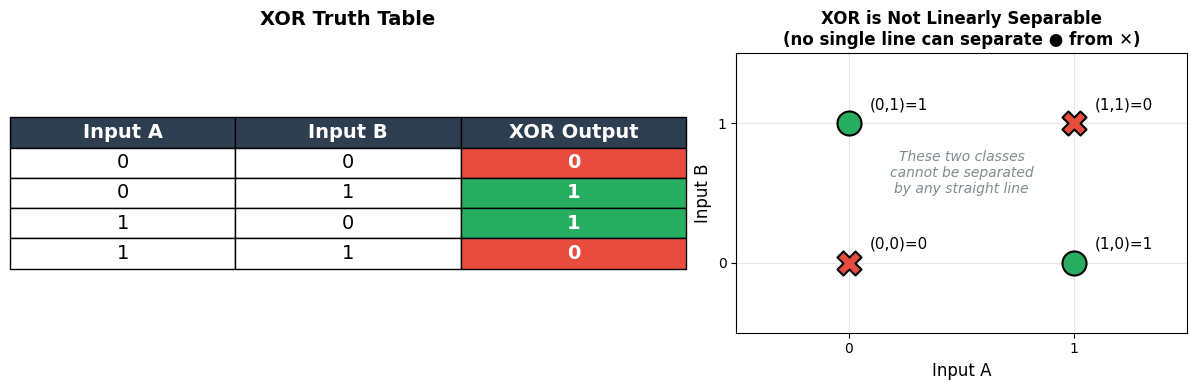

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Truth table as a table visualization
ax1 = axes[0]
ax1.axis('off')
table_data = [['Input A', 'Input B', 'XOR Output'],
              ['0',       '0',       '0'],
              ['0',       '1',       '1'],
              ['1',       '0',       '1'],
              ['1',       '1',       '0']]

table = ax1.table(cellText=table_data[1:],
                  colLabels=table_data[0],
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 2.0)

# Style header row
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style output column — highlight the 1s
for i in range(1, 5):
    xor_val = table_data[i][2]
    if xor_val == '1':
        table[i, 2].set_facecolor('#27ae60')
        table[i, 2].set_text_props(color='white', fontweight='bold')
    else:
        table[i, 2].set_facecolor('#e74c3c')
        table[i, 2].set_text_props(color='white', fontweight='bold')

ax1.set_title('XOR Truth Table', fontsize=14, fontweight='bold', pad=20)

# Plot XOR points in 2D space
ax2 = axes[1]
colors = ['#e74c3c' if label == 0 else '#27ae60' for label in y.flatten()]
markers = ['X' if label == 0 else 'o' for label in y.flatten()]

for i in range(len(X)):
    ax2.scatter(X[i,0], X[i,1],
                c=colors[i],
                marker=markers[i],
                s=300,
                zorder=5,
                edgecolors='black',
                linewidth=1.5)
    ax2.annotate(f'({X[i,0]},{X[i,1]})={y[i,0]}',
                 (X[i,0], X[i,1]),
                 textcoords="offset points",
                 xytext=(15, 10),
                 fontsize=11)

ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('Input A', fontsize=12)
ax2.set_ylabel('Input B', fontsize=12)
ax2.set_title('XOR is Not Linearly Separable\n(no single line can separate ● from ✕)',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])

# Show that no straight line can separate them
ax2.annotate('These two classes\ncannot be separated\nby any straight line',
             xy=(0.5, 0.5),
             fontsize=10,
             ha='center',
             color='#7f8c8d',
             style='italic')

plt.tight_layout()
plt.savefig('xor_truth_table.png', dpi=150, bbox_inches='tight')
plt.show()

## Network Architecture
A 2-layer neural network:
- Input layer: 2 neurons (one per input feature)
- Hidden layer: 4 neurons with sigmoid activation
- Output layer: 1 neuron with sigmoid activation

The hidden layer learns intermediate representations
that make XOR linearly separable before the final prediction.

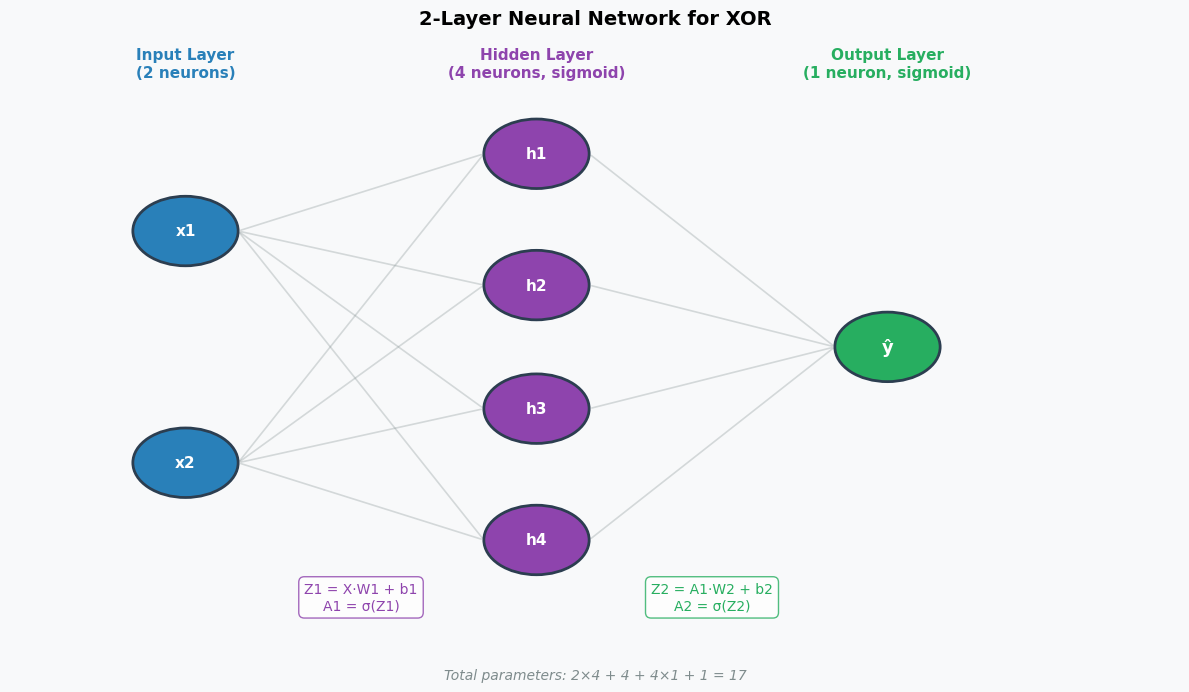

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# --- Node positions ---
input_x  = 1.5
hidden_x = 4.5
output_x = 7.5

input_nodes  = [5.5, 2.5]           # 2 input neurons
hidden_nodes = [6.5, 4.8, 3.2, 1.5] # 4 hidden neurons
output_nodes = [4.0]                 # 1 output neuron

node_radius = 0.45

def draw_node(ax, x, y, label, color, fontsize=11):
    circle = plt.Circle((x, y), node_radius,
                         color=color, zorder=4,
                         ec='#2c3e50', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, label,
            ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', zorder=5)

def draw_connection(ax, x1, y1, x2, y2, alpha=0.3):
    ax.annotate('',
                xy=(x2 - node_radius, y2),
                xytext=(x1 + node_radius, y1),
                arrowprops=dict(arrowstyle='-',
                                color='#7f8c8d',
                                alpha=alpha,
                                lw=1.2),
                zorder=2)

# --- Draw connections ---
for iy, hy in zip(input_nodes, input_nodes):
    for hy in hidden_nodes:
        draw_connection(ax, input_x, iy, hidden_x, hy)

for hy in hidden_nodes:
    for oy in output_nodes:
        draw_connection(ax, hidden_x, hy, output_x, oy)

# --- Draw nodes ---
for i, y in enumerate(input_nodes):
    draw_node(ax, input_x, y, f'x{i+1}', '#2980b9')

for i, y in enumerate(hidden_nodes):
    draw_node(ax, hidden_x, y, f'h{i+1}', '#8e44ad')

draw_node(ax, output_x, output_nodes[0], 'ŷ', '#27ae60', fontsize=13)

# --- Layer labels ---
ax.text(input_x,  7.5, 'Input Layer\n(2 neurons)',
        ha='center', fontsize=11, fontweight='bold', color='#2980b9')
ax.text(hidden_x, 7.5, 'Hidden Layer\n(4 neurons, sigmoid)',
        ha='center', fontsize=11, fontweight='bold', color='#8e44ad')
ax.text(output_x, 7.5, 'Output Layer\n(1 neuron, sigmoid)',
        ha='center', fontsize=11, fontweight='bold', color='#27ae60')

# --- Math annotations ---
ax.text(3.0, 0.6,
        'Z1 = X·W1 + b1\nA1 = σ(Z1)',
        ha='center', fontsize=10,
        color='#8e44ad',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='#8e44ad',
                  alpha=0.8))

ax.text(6.0, 0.6,
        'Z2 = A1·W2 + b2\nA2 = σ(Z2)',
        ha='center', fontsize=10,
        color='#27ae60',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='#27ae60',
                  alpha=0.8))

# --- Parameter count ---
ax.text(5.0, -0.3,
        'Total parameters: 2×4 + 4 + 4×1 + 1 = 17',
        ha='center', fontsize=10,
        color='#7f8c8d', style='italic')

ax.set_title('2-Layer Neural Network for XOR',
             fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('network_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

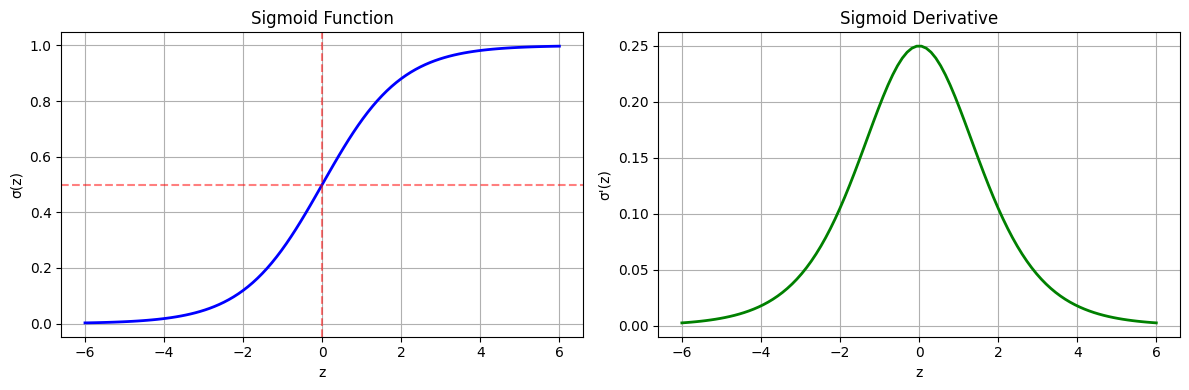

Note: derivative peaks at 0.25 when z=0, approaches 0 at extremes
This is the vanishing gradient problem - gradients die at saturated neurons


In [25]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Visualize sigmoid and its derivative
z = np.linspace(-6, 6, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_derivative(z), 'g-', linewidth=2)
plt.title('Sigmoid Derivative')
plt.xlabel('z')
plt.ylabel("σ'(z)")
plt.grid(True)

plt.tight_layout()
plt.savefig('sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: derivative peaks at 0.25 when z=0, approaches 0 at extremes")
print("This is the vanishing gradient problem - gradients die at saturated neurons")

In [26]:
np.random.seed(42)

# Network architecture: 2 inputs → 4 hidden neurons → 1 output
input_size  = 2
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape, "— maps 2 inputs to 4 hidden neurons")
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape, "— maps 4 hidden neurons to 1 output")
print("b2 shape:", b2.shape)
print("\nTotal parameters:", W1.size + b1.size + W2.size + b2.size)

W1 shape: (2, 4) — maps 2 inputs to 4 hidden neurons
b1 shape: (1, 4)
W2 shape: (4, 1) — maps 4 hidden neurons to 1 output
b2 shape: (1, 1)

Total parameters: 17


## The Mathematics

### Forward Pass
Given input X, the network computes:

**Hidden layer:**
Z1 = X · W1 + b1;
A1 = sigmoid(Z1)

**Output layer:**
Z2 = A1 · W2 + b2;
A2 = sigmoid(Z2)

### Loss Function (Binary Cross Entropy)
L = -1/n · Σ [y·log(A2) + (1-y)·log(1-A2)]

### Backward Pass (Chain Rule)
The gradient of loss with respect to each weight:

dL/dW2 = A1ᵀ · dZ2;
dL/dW1 = Xᵀ · dZ1

Where:
dZ2 = A2 - y;
dZ1 = (dZ2 · W2ᵀ) · sigmoid'(Z1)

### Weight Update (Gradient Descent)
W = W - α · dL/dW
b = b - α · dL/db

Where α is the learning rate

In [27]:
def forward(X, W1, b1, W2, b2):
    # Hidden layer
    Z1 = np.dot(X, W1) + b1      # (4,2)·(2,4) = (4,4)
    A1 = sigmoid(Z1)              # apply activation

    # Output layer
    Z2 = np.dot(A1, W2) + b2     # (4,4)·(4,1) = (4,1)
    A2 = sigmoid(Z2)              # final prediction

    cache = (Z1, A1, Z2, A2)
    return A2, cache

def compute_loss(A2, y):
    n = y.shape[0]
    # Binary cross entropy
    loss = -1/n * np.sum(y * np.log(A2 + 1e-8) +
                         (1-y) * np.log(1 - A2 + 1e-8))
    return loss

# Redefine to be safe
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y values:", y.flatten())

# Test forward pass before training
A2_init, cache_init = forward(X, W1, b1, W2, b2)
loss_init = compute_loss(A2_init, y)
print("Initial predictions (untrained):")
print(A2_init)
print("\nInitial loss:", loss_init)
print("Expected: ~0.693 (log 2) for random predictions")

X shape: (4, 2)
y shape: (4, 1)
y values: [0 1 1 0]
Initial predictions (untrained):
[[0.44669943]
 [0.43029337]
 [0.42699871]
 [0.41263144]]

Initial loss: 0.7045547302807305
Expected: ~0.693 (log 2) for random predictions


In [28]:
def backward(X, y, cache, W2):
    Z1, A1, Z2, A2 = cache
    n = y.shape[0]

    # Output layer gradients
    dZ2 = A2 - y                          # (4,1)
    dW2 = np.dot(A1.T, dZ2) / n          # (4,4)ᵀ·(4,1) = (4,1)
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n        # (1,1)

    # Hidden layer gradients (chain rule through sigmoid)
    dA1 = np.dot(dZ2, W2.T)              # (4,1)·(4,1)ᵀ = (4,4)
    dZ1 = dA1 * sigmoid_derivative(Z1)   # element-wise
    dW1 = np.dot(X.T, dZ1) / n          # (2,4)ᵀ·(4,4) = (2,4)
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n       # (1,4)

    grads = (dW1, db1, dW2, db2)
    return grads

## Why dZ2 = A2 - y

The gradient of loss w.r.t Z2 combines two steps:
dLoss/dZ2 = dLoss/dA2 · dA2/dZ2

dLoss/dA2 = -y/A2 + (1-y)/(1-A2)     (cross entropy derivative)
dA2/dZ2   = A2·(1-A2)                  (sigmoid derivative)

Multiplying and simplifying:
= A2 - y

Binary cross entropy + sigmoid were designed together
to produce this clean cancellation.

In [29]:
def train(X, y, learning_rate=1.0, epochs=10000):
    # Initialize weights
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):
        # Forward pass
        A2, cache = forward(X, W1, b1, W2, b2)

        # Compute loss
        loss = compute_loss(A2, y)
        loss_history.append(loss)

        # Backward pass
        dW1, db1, dW2, db2 = backward(X, y, cache, W2)

        # Update weights
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train(X, y)

Epoch     0 | Loss: 0.704555
Epoch  1000 | Loss: 0.028426
Epoch  2000 | Loss: 0.006148
Epoch  3000 | Loss: 0.003349
Epoch  4000 | Loss: 0.002284
Epoch  5000 | Loss: 0.001728
Epoch  6000 | Loss: 0.001387
Epoch  7000 | Loss: 0.001158
Epoch  8000 | Loss: 0.000993
Epoch  9000 | Loss: 0.000868


Final Predictions vs Truth:
Input           Predicted    Rounded    Truth
---------------------------------------------
[0 0]            0.001083          0        0 ✓
[0 1]            0.999296          1        1 ✓
[1 0]            0.999283          1        1 ✓
[1 1]            0.000580          0        0 ✓


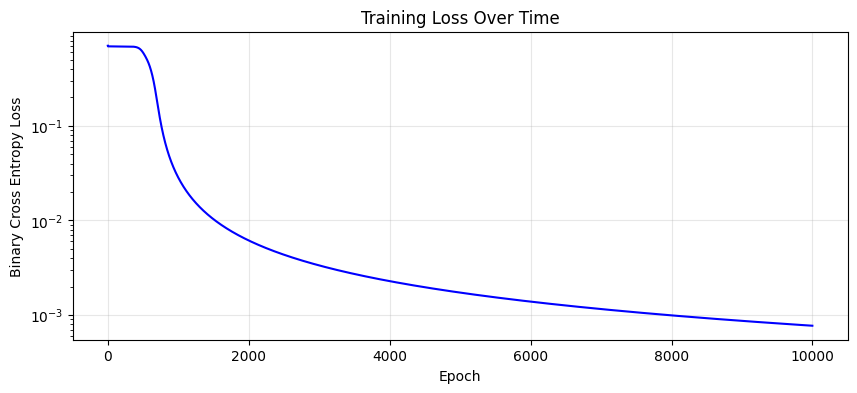


Final loss: 0.000772


In [30]:
# Final predictions
A2_final, _ = forward(X, W1, b1, W2, b2)

print("Final Predictions vs Truth:")
print(f"{'Input':<12} {'Predicted':>12} {'Rounded':>10} {'Truth':>8}")
print("-" * 45)
for i in range(len(X)):
    pred = A2_final[i][0]
    rounded = round(pred)
    truth = y[i][0]
    correct = "✓" if rounded == truth else "✗"
    print(f"{str(X[i]):<12} {pred:>12.6f} {rounded:>10} {truth:>8} {correct}")

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, 'b-', linewidth=1.5)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFinal loss: {loss_history[-1]:.6f}")

In [31]:
Z1_test = np.dot(X, W1) + b1
print("X shape:", X.shape)
print("W1 shape:", W1.shape)
print("Z1 shape:", Z1_test.shape)
print("\nZ1 values:")
print(np.round(Z1_test, 3))

X shape: (4, 2)
W1 shape: (2, 4)
Z1 shape: (4, 4)

Z1 values:
[[-6.819  1.096 -7.29  -3.709]
 [-2.491  0.95  -2.638  4.226]
 [-2.503  1.031 -2.656  4.241]
 [ 1.825  0.885  1.997 12.176]]


In [32]:
A1_test = sigmoid(Z1_test)
print("A1 shape:", A1_test.shape)
print("\nA1 values (hidden layer activations):")
print(np.round(A1_test, 3))
print("\nFor each row, which hidden neurons are firing strongly (>0.5)?")
for i, row in enumerate(A1_test):
    firing = np.where(row > 0.5)[0]
    print(f"Input {X[i]}: neurons {firing} are active")

A1 shape: (4, 4)

A1 values (hidden layer activations):
[[0.001 0.75  0.001 0.024]
 [0.077 0.721 0.067 0.986]
 [0.076 0.737 0.066 0.986]
 [0.861 0.708 0.88  1.   ]]

For each row, which hidden neurons are firing strongly (>0.5)?
Input [0 0]: neurons [1] are active
Input [0 1]: neurons [1 3] are active
Input [1 0]: neurons [1 3] are active
Input [1 1]: neurons [0 1 2 3] are active


In [33]:
print("W2 weights (hidden → output):")
for i, w in enumerate(W2):
    print(f"Neuron {i} → output weight: {w[0]:.4f}")

print("\nFor input (0,0) - only neuron 1 active:")
a1_00 = A1_test[0]
contribution_00 = a1_00 * W2.flatten()
print("Contributions:", np.round(contribution_00, 4))
print("Sum + bias:", np.round(np.sum(contribution_00) + b2[0][0], 4))

print("\nFor input (1,1) - all neurons active:")
a1_11 = A1_test[3]
contribution_11 = a1_11 * W2.flatten()
print("Contributions:", np.round(contribution_11, 4))
print("Sum + bias:", np.round(np.sum(contribution_11) + b2[0][0], 4))

W2 weights (hidden → output):
Neuron 0 → output weight: -8.9393
Neuron 1 → output weight: -2.5332
Neuron 2 → output weight: -9.7805
Neuron 3 → output weight: 15.9436

For input (0,0) - only neuron 1 active:
Contributions: [-0.0098 -1.8988 -0.0067  0.3813]
Sum + bias: -6.8267

For input (1,1) - all neurons active:
Contributions: [-7.6982 -1.793  -8.6113 15.9435]
Sum + bias: -7.4517


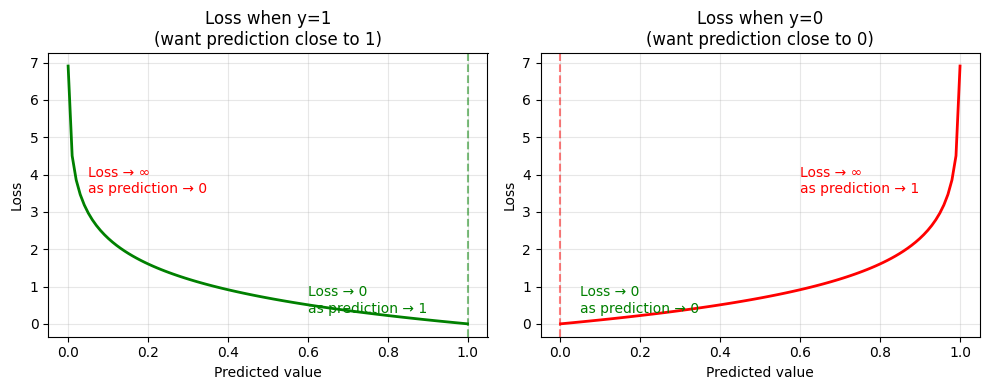

In [34]:
# Visualize what the loss function feels like
import numpy as np
import matplotlib.pyplot as plt

predictions = np.linspace(0.001, 0.999, 100)

loss_when_y1 = -np.log(predictions)        # when true label is 1
loss_when_y0 = -np.log(1 - predictions)    # when true label is 0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(predictions, loss_when_y1, 'g-', linewidth=2)
plt.title('Loss when y=1\n(want prediction close to 1)')
plt.xlabel('Predicted value')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.axvline(x=1.0, color='g', linestyle='--', alpha=0.5, label='perfect prediction')
plt.annotate('Loss → ∞\nas prediction → 0',
             xy=(0.05, 3.5), fontsize=10, color='red')
plt.annotate('Loss → 0\nas prediction → 1',
             xy=(0.6, 0.3), fontsize=10, color='green')

plt.subplot(1, 2, 2)
plt.plot(predictions, loss_when_y0, 'r-', linewidth=2)
plt.title('Loss when y=0\n(want prediction close to 0)')
plt.xlabel('Predicted value')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.axvline(x=0.0, color='r', linestyle='--', alpha=0.5, label='perfect prediction')
plt.annotate('Loss → 0\nas prediction → 0',
             xy=(0.05, 0.3), fontsize=10, color='green')
plt.annotate('Loss → ∞\nas prediction → 1',
             xy=(0.6, 3.5), fontsize=10, color='red')

plt.tight_layout()
plt.savefig('loss_function.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:

# Show what happens without /n
dZ2_test = A2_init - y
print("dZ2 shape:", dZ2_test.shape)
print("dZ2 values:", dZ2_test.flatten())

# Without averaging
dW2_raw = np.dot(A1_test.T, dZ2_test)
print("\ndW2 without /n:", dW2_raw.flatten())

# With averaging
dW2_avg = np.dot(A1_test.T, dZ2_test) / len(X)
print("dW2 with /n:   ", dW2_avg.flatten())

print("\nRatio:", np.round(dW2_raw.flatten() / dW2_avg.flatten(), 1))

dZ2 shape: (4, 1)
dZ2 values: [ 0.44669943 -0.56970663 -0.57300129  0.41263144]

dW2 without /n: [ 0.26889129 -0.20630466  0.28797476 -0.70306502]
dW2 with /n:    [ 0.06722282 -0.05157617  0.07199369 -0.17576625]

Ratio: [4. 4. 4. 4.]


In [36]:
db2_test = np.sum(dZ2_test, axis=0) / len(X)
print("db2:", db2_test)
print("shape:", db2_test.shape)
print("\nManual check - sum of dZ2 values / 4:")
print(np.sum(dZ2_test) / 4)

db2: [-0.07084426]
shape: (1,)

Manual check - sum of dZ2 values / 4:
-0.0708442616007605


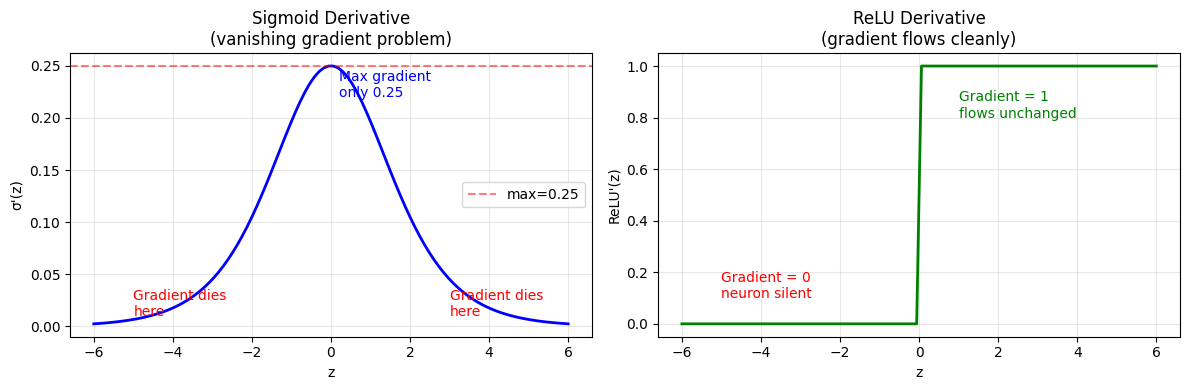

In [37]:
z = np.linspace(-6, 6, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid_derivative(z), 'b-', linewidth=2)
plt.title('Sigmoid Derivative\n(vanishing gradient problem)')
plt.xlabel('z')
plt.ylabel("σ'(z)")
plt.grid(True, alpha=0.3)
plt.axhline(y=0.25, color='r', linestyle='--',
            alpha=0.5, label='max=0.25')
plt.legend()
plt.annotate('Gradient dies\nhere',
             xy=(-5, 0.01), fontsize=10, color='red')
plt.annotate('Gradient dies\nhere',
             xy=(3, 0.01), fontsize=10, color='red')
plt.annotate('Max gradient\nonly 0.25',
             xy=(0.2, 0.22), fontsize=10, color='blue')

plt.subplot(1, 2, 2)
plt.plot(z, (z > 0).astype(float), 'g-', linewidth=2)
plt.title('ReLU Derivative\n(gradient flows cleanly)')
plt.xlabel('z')
plt.ylabel("ReLU'(z)")
plt.grid(True, alpha=0.3)
plt.annotate('Gradient = 1\nflows unchanged',
             xy=(1, 0.8), fontsize=10, color='green')
plt.annotate('Gradient = 0\nneuron silent',
             xy=(-5, 0.1), fontsize=10, color='red')

plt.tight_layout()
plt.savefig('vanishing_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

## Vanishing Gradient Problem

When sigmoid is used in hidden layers, the derivative
σ'(z) = σ(z)·(1-σ(z)) has a maximum value of only 0.25.

For saturated neurons (z very large or small), σ'(z) → 0.
In deep networks this compounds across layers:
gradient ∝ 0.25^n where n is number of layers

This is why modern networks use ReLU in hidden layers:
- ReLU'(z) = 1 for z > 0 (gradient flows unchanged)
- ReLU'(z) = 0 for z < 0 (neuron silent, but not saturating)

Our XOR network uses sigmoid throughout for simplicity,
but a real production network would use ReLU in hidden layers.

In [39]:
print("W1:", W1.shape, "| dW1:", dW1_t.shape)
print("b1:", b1.shape, "| db1:", db1_t.shape)
print("W2:", W2.shape, "| dW2:", dW2_t.shape)
print("b2:", b2.shape, "| db2:", db2_t.shape)

# Reshape bias gradients to match
db1_t = db1_t.reshape(b1.shape)
db2_t = db2_t.reshape(b2.shape)

print("\nAfter reshape:")
print("b1:", b1.shape, "| db1:", db1_t.shape, "| match:", b1.shape == db1_t.shape)
print("b2:", b2.shape, "| db2:", db2_t.shape, "| match:", b2.shape == db2_t.shape)

W1: (2, 4) | dW1: (2, 4)
b1: (1, 4) | db1: (4,)
W2: (4, 1) | dW2: (4, 1)
b2: (1, 1) | db2: (1,)

After reshape:
b1: (1, 4) | db1: (1, 4) | match: True
b2: (1, 1) | db2: (1, 1) | match: True
